Use case
My loan company team looks at application forms that do not have customer names. They only see things like income, loan amount, and credit history.
They need to decide, for each application:

Easy file — credit looks fine, loan is not too big for their income → move it forward quickly
Incomplete file — credit history is missing → get that record first
Risky file — credit history is bad → a senior officer should check it carefully

Why this matters: the team cannot treat every form the same. This file helps them know which applications to handle first and which need extra checking.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make tables show more columns
pd.set_option("display.max_columns", None)

# make plots a bit nicer
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [20]:
df = pd.read_csv("raw_data.csv")
df.head(20)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,m,Yes,0,Graduate,No,5720,0.0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500.0,126.0,360.0,1.0,Uban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800.0,208.0,360.0,1.0,Urban
3,LP001035,m,Yes,2,Graduate,No,2340,2546.0,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0.0,78.0,360.0,1.0,Urban
5,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422.0,152.0,360.0,1.0,Urban
6,LP001055,Female,No,1,Not Graduate,No,2226,0.0,59.0,360.0,1.0,Semiurban
7,LP001056,m,Yes,2,Not Graduate,No,3881,0.0,147.0,360.0,0.0,Rurl
8,LP001059,Male,Yes,2,Graduate,NaN,13633,0.0,280.0,240.0,1.0,Urban
9,LP001067,Male,No,0,Not Graduate,No,2400,2400.0,123.0,360.0,1.0,Semiurban


In [ ]:
%pip install pandas numpy matplotlib seaborn

## Data quality issues (before cleaning)

### Already fine
- 981 rows, 12 columns
- Loan_ID has no duplicates
- Education is clean (`Graduate`, `Not Graduate`)
- ApplicantIncome and CoapplicantIncome have no missing values

### Wrong format / inconsistent labels
- **Gender:** written as `Male`, `m`, `Female`, `f`
- **Property_Area:** many spellings (`Uban`, `Urben`, `Urbun`, `Urbn`, `Rurl`, `Rurall`, `Rurel`, `Rual`, `Semiurbn`, `Semurban`, `Semiurben`, etc.)

### Missing values
- Gender: 24
- Married: 3
- Dependents: 25
- Self_Employed: 55
- LoanAmount: 27
- Loan_Amount_Term: 20
- Credit_History: 79

### Other issues
- Dependents uses `3+` (text, not a number)
- Credit_History uses `1` and `0` instead of clear labels
- ApplicantIncome is `0` on 2 rows
- Some income and loan amounts are unusually high (outliers)

### Wrong data types
- **Credit_History** is stored as `float` (`1.0`, `0.0`). It should be a label: `Good`, `Bad`, `Missing`
- **Loan_Amount_Term** is stored as `float` (`360.0`) because of missing values. After filling blanks, change it to `int`
- **LoanAmount** is stored as `float` because of missing values. After filling blanks, change it to `int` if all values are whole numbers
- **Dependents** looks like numbers but must stay text because of `3+`
- **CoapplicantIncome** is `float`. Leave it as `float` (some values have decimals)
- **ApplicantIncome** is already `int` — no change needed

In [22]:
df.isna().sum()

Loan_ID               0
Gender               24
Married               3
Dependents           25
Education             0
Self_Employed        55
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           27
Loan_Amount_Term     20
Credit_History       79
Property_Area         0
dtype: int64

In [23]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
dtype: object

In [24]:
clean = df.copy()

In [25]:
clean["Gender"] = (
    clean["Gender"]
    .replace({"m": "Male", "f": "Female"})
)

area_fix = {
    "Uban": "Urban", "Urben": "Urban", "Urbun": "Urban", "Urbn": "Urban",
    "Rurl": "Rural", "Rurall": "Rural", "Rurel": "Rural", "Rual": "Rural",
    "Semiurbn": "Semiurban", "Semurban": "Semiurban", "Semiurben": "Semiurban",
}
clean["Property_Area"] = clean["Property_Area"].replace(area_fix)

In [26]:
clean["Gender"] = clean["Gender"].fillna(clean["Gender"].mode()[0])
clean["Married"] = clean["Married"].fillna(clean["Married"].mode()[0])
clean["Dependents"] = clean["Dependents"].fillna(clean["Dependents"].mode()[0])
clean["Self_Employed"] = clean["Self_Employed"].fillna(clean["Self_Employed"].mode()[0])

clean["LoanAmount"] = clean["LoanAmount"].fillna(clean["LoanAmount"].median())
clean["Loan_Amount_Term"] = clean["Loan_Amount_Term"].fillna(clean["Loan_Amount_Term"].mode()[0])

In [27]:
clean["Credit_History"] = clean["Credit_History"].map({1.0: "Good", 0.0: "Bad"})
clean["Credit_History"] = clean["Credit_History"].fillna("Missing")

In [28]:
clean["Loan_Amount_Term"] = clean["Loan_Amount_Term"].astype(int)
clean["LoanAmount"] = clean["LoanAmount"].astype(int)

In [31]:
print(clean.isna().sum())
print(clean.dtypes)
print(clean["Credit_History"].value_counts())
clean.head(20)

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64
Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount             int64
Loan_Amount_Term       int64
Credit_History           str
Property_Area            str
dtype: object
Credit_History
Good       754
Bad        148
Missing     79
Name: count, dtype: int64


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0.0,110,360,Good,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500.0,126,360,Good,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800.0,208,360,Good,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546.0,100,360,Missing,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0.0,78,360,Good,Urban
5,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422.0,152,360,Good,Urban
6,LP001055,Female,No,1,Not Graduate,No,2226,0.0,59,360,Good,Semiurban
7,LP001056,Male,Yes,2,Not Graduate,No,3881,0.0,147,360,Bad,Rural
8,LP001059,Male,Yes,2,Graduate,No,13633,0.0,280,240,Good,Urban
9,LP001067,Male,No,0,Not Graduate,No,2400,2400.0,123,360,Good,Semiurban


In [33]:
clean.shape
clean.describe(include="all")

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
count,981,981,981,981,981,981,981.000000,981.000000,981.000000,981.000000,981,981
unique,981,2,2,4,2,2,NaN,NaN,NaN,NaN,3,3
top,LP001015,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,Good,Semiurban
freq,1,799,634,570,763,862,NaN,NaN,NaN,NaN,754,349
mean,NaN,NaN,NaN,NaN,NaN,NaN,5179.795107,1601.916330,142.057085,342.564730,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,5695.104533,2718.772806,76.395592,64.482011,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,9.000000,6.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2875.000000,0.000000,101.000000,360.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3800.000000,1110.000000,126.000000,360.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5516.000000,2365.000000,160.000000,360.000000,NaN,NaN


1. How many applicants have Good credit, Bad credit, or Missing credit?
2. Is Bad credit more common for some groups — education, dependents, married, property area, gender?
3. Do Bad-credit applicants ask for bigger loans, or earn less, than Good-credit applicants?

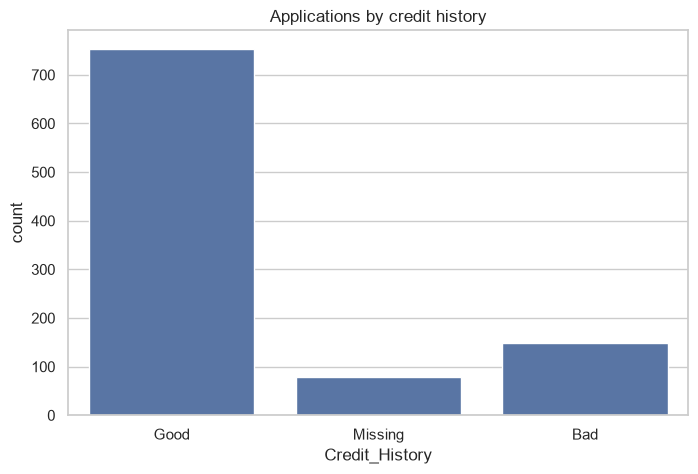

In [37]:
# How many applicants have Good credit, Bad credit, or Missing credit?

plt.figure()
sns.countplot(data=clean, x="Credit_History", order=["Good", "Missing", "Bad"])
plt.title("Applications by credit history")
plt.show()

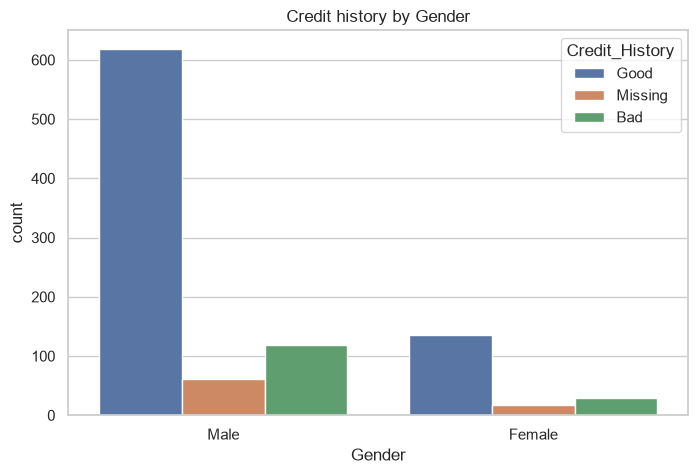

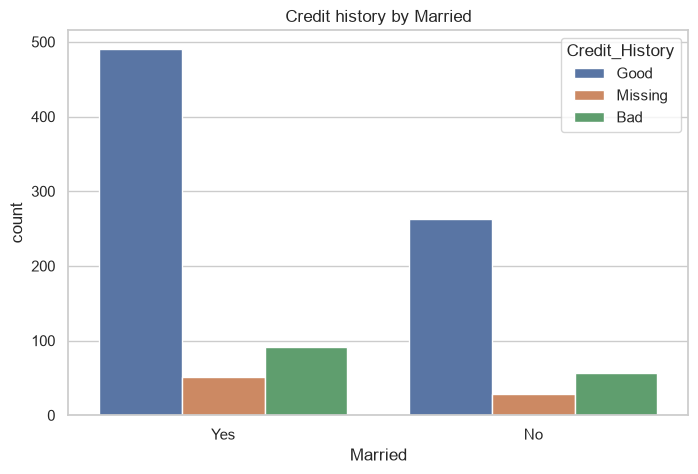

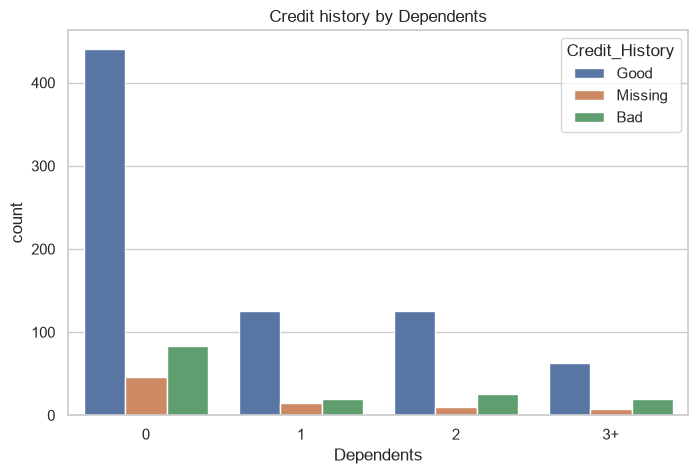

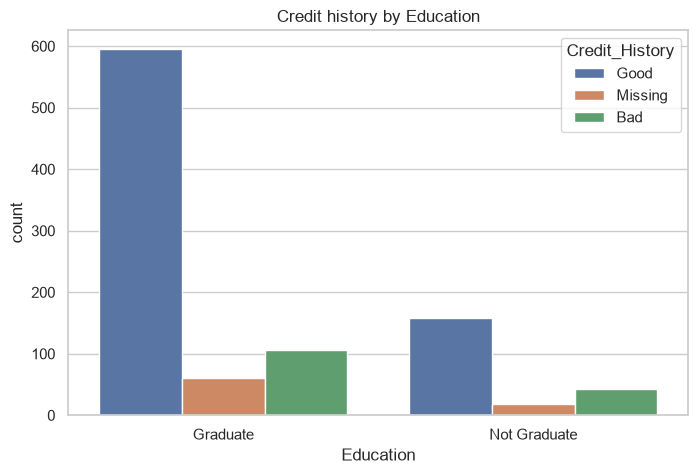

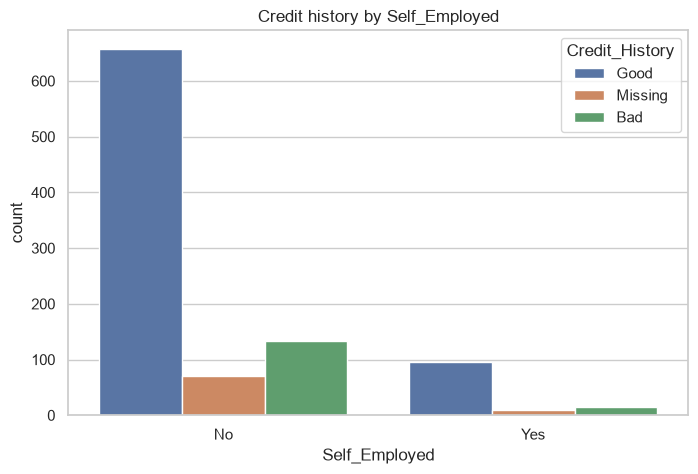

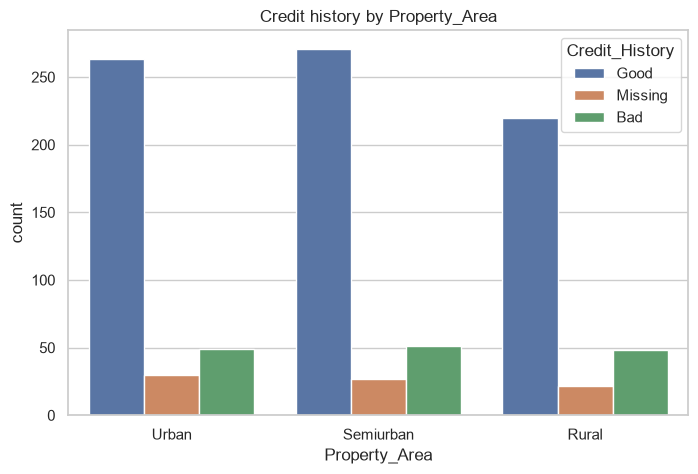

In [ ]:
# Is Bad credit more common for some groups — education, dependents, married, property area, gender?

groups = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]

for col in groups:
    plt.figure()
    sns.countplot(data=clean, x=col, hue="Credit_History")
    plt.title(f"Credit history by {col}")
    plt.show()

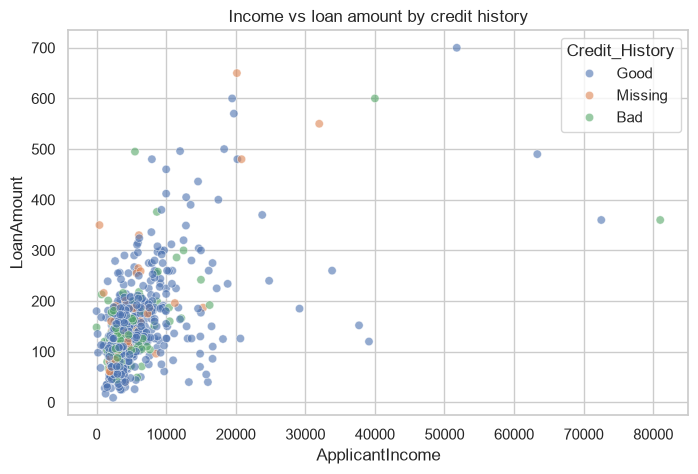

In [ ]:
# Do Bad-credit applicants ask for bigger loans, or earn less, than Good-credit applicants?

plt.figure()
sns.scatterplot(data=clean, x="ApplicantIncome", y="LoanAmount", hue="Credit_History", alpha=0.6)
plt.title("Income vs loan amount by credit history")
plt.show()

Most applicants have good credit history. Bad credit and missing credit are much smaller groups, and this pattern appears across education, dependents, gender, marriage status, and property area.
Typical income and loan amount are similar for good-credit and bad-credit applicants, so the team cannot judge risk from money alone.
The useful decision is to sort applications by credit history: move good-credit files forward quickly, hold files with missing credit until the record is found, and send bad-credit files for extra checking